In [1]:
import subprocess
import re
from statistics import mean
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": [13, 8], "font.size": 18})

**FIXME: for the "create" case it doesn't make sense to compare the size increase in memory related to the input file size, since there is no input file size**

In [2]:
def run_one(exe, file, architecture, case):
    res = subprocess.run(["/usr/bin/time", "-v", exe, file, "--architecture", architecture, "--case", case],
                         check=True, capture_output=True)
    mrss = re.search(r"(Maximum resident set size \(kbytes\): )([0-9]+)", res.stderr.decode("utf-8"))
    mut = re.search(r"(User time \(seconds\): )([0-9]+\.[0-9]+)", res.stderr.decode("utf-8"))
    return float(mut[2]), int(mrss[2])

def run_file(exe, file: Path, n_iter=10):
    """filename, architecture, case, user_time, max_rss, pct_increase, file_size"""
    architectures = ["direct-json", "dereference"]
    cases = ["deserialize", "geometry", "semantics", "create"]
    for a in architectures:
        for c in cases:
            res_iter = [run_one(exe, file, a, c) for i in range(n_iter)]
            res_ut = sum(i[0] for i in res_iter) / n_iter
            res_rss = sum(i[1] for i in res_iter) / n_iter
            pct_increase = round(res_rss / (file.stat().st_size * 0.001) * 100, 0)
            yield file.stem.replace("_bench.city", ""), a, c, res_ut, res_rss, pct_increase, file.stat().st_size * 0.001
            
def run_files(exe, files):
    for file in files:
        for r in run_file(exe, file):
            yield r

In [3]:
bench_files = [
    Path("/home/balazs/Development/cjlib/experiments/data/cluster_bench.city.json"),
    Path("/home/balazs/Development/cjlib/experiments/data/3dbag_v210908_fd2cee53_5786_bench.city.json")
]
exe = "/home/balazs/Development/cjlib/experiments/benchmark/target/release/benchmark"

res_gen = run_files(exe, bench_files)
results = pd.DataFrame(data=res_gen, 
                       columns=["filename", "architecture", "case", "user_time_s", 
                                "max_rss_kb", "size_increase_pct", "file_size_kb"])

In [4]:
results

,filename,architecture,case,user_time_s,max_rss_kb,size_increase_pct,file_size_kb
0,cluster,direct-json,deserialize,0.000,2917.6,19992.0,14.594
1,cluster,direct-json,geometry,0.000,2936.8,20123.0,14.594
2,cluster,direct-json,semantics,0.000,2914.0,19967.0,14.594
3,cluster,direct-json,create,0.000,2831.6,19402.0,14.594
4,cluster,dereference,deserialize,0.000,2949.2,20208.0,14.594
5,cluster,dereference,geometry,0.000,2967.6,20334.0,14.594
6,cluster,dereference,semantics,0.000,2948.0,20200.0,14.594
7,cluster,dereference,create,0.000,2795.6,19156.0,14.594
8,3dbag_v210908_fd2cee53_5786,direct-json,deserialize,0.155,79195.6,1012.0,7825.320
9,3dbag_v210908_fd2cee53_5786,direct-json,geometry,0.168,89500.4,1144.0,7825.320


In [5]:
def plot_size_increase(filename):
    ax = (results[results.filename==filename]
              .set_index("architecture")[["case", "size_increase_pct"]]
             .pivot(columns="case", values="size_increase_pct")
             .plot.bar())
    fsize_mb = round(float(results[results.filename==filename][0:1]["file_size_kb"]*0.001), 2)
    ax.set_title(f"File: {filename} | {fsize_mb}Mb")
    ax.set_ylabel("Size increase in memory compared to file size [%]")

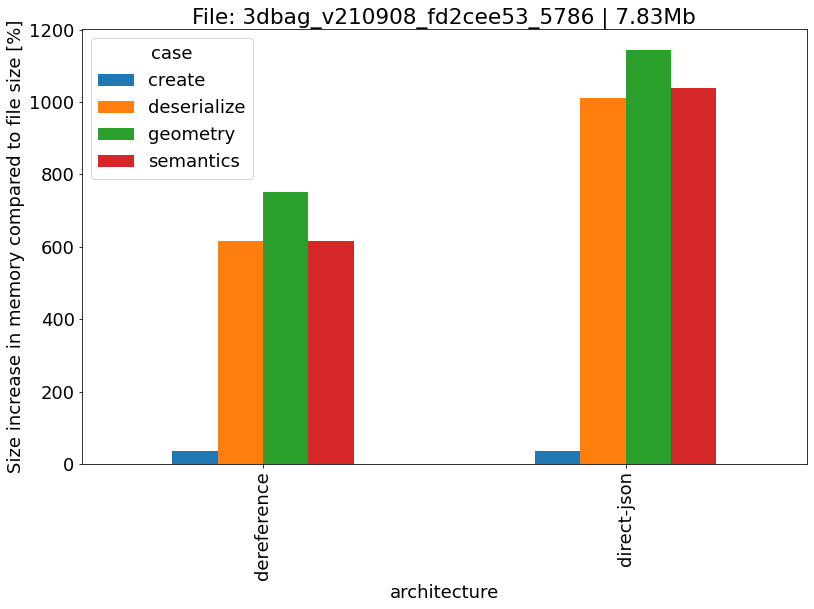

In [6]:
plot_size_increase("3dbag_v210908_fd2cee53_5786")

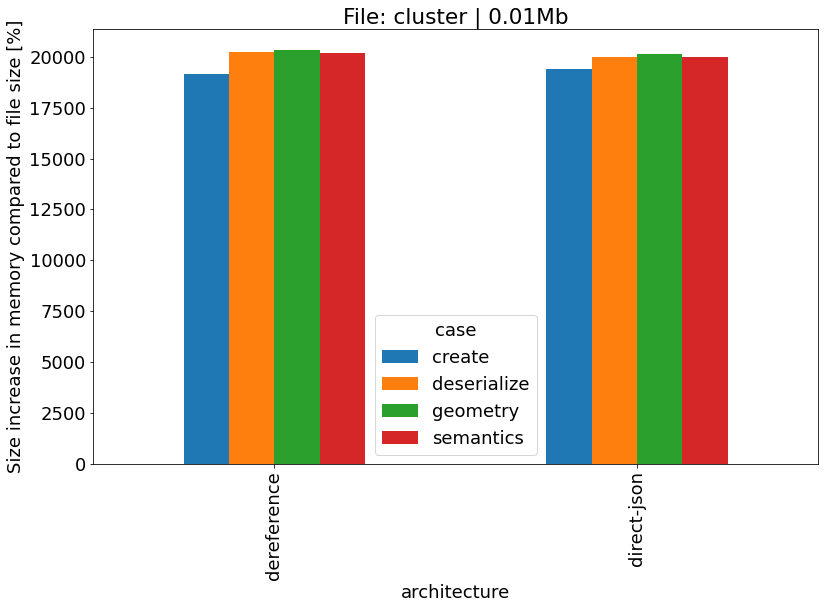

In [7]:
plot_size_increase("cluster")